# Fully Sharded Data Parallel (FSDP)
Author: Tomasz Kanas

FSDP is the Pytorch implementation of the Zero Redundancy Optimizer (ZeRO).

The main idea in FSDP is to distribute the training data and model parameters among all GPUs. Then to make a forward pass all parameters need to be gathered every node - this is the All Gather operation. Then we perform the forward and backward pass, discard the parameters and distribute the gradients among the nodes - each node needs to gather the sum of gradients corresponding to the shard of the parameters it holds. This is called a Reduce Scatter operation. Finally the optimizer step can be performed independently on each node.

The crucial observation is that, when using mixed-precision, the optimizer state actually dominates the memory consumption. In the case of Adam, we need to store 3 numbers, each 32bit: state, momentum and variance (and we can't use 16bit precision here - it will cause instability in training), while we need only 2 16bit numbers for training: parameter and gradient (and activations, but there are other metods to optimize their storage, like checkpointing). Using FSDP each node needs to keep only a fraction of parameters, and thus fraction of optimizer states, what largely saves the memory

But FSDP goes a step further: we can also combine this method with the pipeline parallelism. We can wrap some sets of layers of our model in "FSDP Units". Then after the forward pass of each unit, FSDP will discard the parameters of this unit, and All-Gather them again before the backward pass.

See this [animation](https://www.microsoft.com/en-us/research/uploads/prod/2020/02/Turing-Animation.mp4?_=1) that visualizes how the algorithm works.

On the image below there are visualized differences with different types of sharding the model.

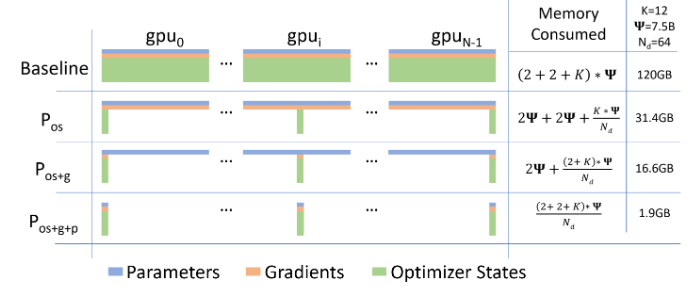

Although splitting the model into many FSDP units causes more communication, it also allows to overlap communication with computation. For example consider the 5-layer model with units displayed on the image below:

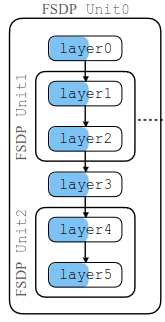

Then the schedule could have looked like:

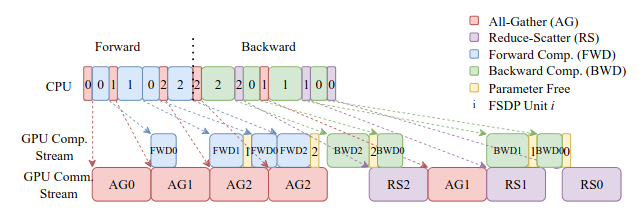

Note: there are two mistakes in this schedule:
 - The second AG2 step is redundant, as we compute the backward pass of the Unit2 just after the first pass, so there is no sense in freeing parameters to gather them immediately. We assume that FSDP developers were smart enough to implement such a simple if statement.

 - The RS1 step should start after the end of the BWD1 step because it scatters the gradients that will be counted in the BWD1 step.

### Excercise (on the blackboard):
Let's consider the model split along the image above. Assume that all layers are fully connected, without bias. The input is a vector of length 100, and the outputs of the layers have lengths:

- 100, 200, 200, 200, 100, 100

Thus, the number of parameters in consecutive layers is:

- 10k, 20k, 40k, 40k, 20k, 10k

Let's assume that we use mixed precision with 16 bits for parameter and gradient, and the optimizer is Adam, so the optimizer state consists of 3 floats (parameter, momentum, variance) with 32-bit precision. We use 10 nodes, and the batch size on a single node is also 10.

Compute the memory usage for every moment of the above schedule.

### Excercise 2 (on the blackboard)

Draw the schedule, and compute the memory for the model above, when every layer is in the separate FSDP unit. You can do this excercise just for the first 3 layers.

## Experiments on the Entropy
IMPORTANT: please don't create a jupyter session on entropy. In this lab you will need many graphic cards. If everyone in the lab reserves many graphic cards for the jupyter session we may block the queue.

### Setup to work from colab (optional)
First let's start from setting up some environment values:

In [ ]:
# Change values of those variables to your login and QOS
%env ENTROPY_LOGIN=kp438667
%env QOS=kp438667_common

env: ENTROPY_LOGIN=kp438667
env: QOS=kp438667_common


And creating the SSH keys:

In [ ]:
!mkdir .ssh
!ssh-keygen -t ed25519 -f .ssh/id_ed25519 -N '' -C $ENTROPY_LOGIN

Generating public/private ed25519 key pair.
Your identification has been saved in .ssh/id_ed25519
Your public key has been saved in .ssh/id_ed25519.pub
The key fingerprint is:
SHA256:p5VvhPSU2UURdLlT6TljFK+rEzOerAmr507Vgjkl5xw kp438667
The key's randomart image is:
+--[ED25519 256]--+
|              .*X|
|             + =+|
|        . E + + =|
|         X B   X |
|        S X + o +|
|         * ++  . |
|        +  oo=.  |
|       ..o o=.   |
|      .=+ o...   |
+----[SHA256]-----+


Now copy the public key from the .ssh directory and paste it to the `.ssh/authorized_keys` on entropy.



In [ ]:
!cat .ssh/id_ed25519.pub

ssh-ed25519 AAAAC3NzaC1lZDI1NTE5AAAAIHv3JIIG3OKFd2qTHfQb8cob/4lXnvXFR6krMM6b1HUL kp438667


Add the entropy public key to the known_hosts:

In [ ]:
!mkdir /root/.ssh
!touch /root/.ssh/known_hosts
!ssh-keygen -R entropy.mimuw.edu.pl
!ssh-keyscan entropy.mimuw.edu.pl | tee -a /root/.ssh/known_hosts

Host entropy.mimuw.edu.pl not found in /root/.ssh/known_hosts
# entropy.mimuw.edu.pl:22 SSH-2.0-OpenSSH_9.6p1 Ubuntu-3ubuntu13.14
# entropy.mimuw.edu.pl:22 SSH-2.0-OpenSSH_9.6p1 Ubuntu-3ubuntu13.14
# entropy.mimuw.edu.pl:22 SSH-2.0-OpenSSH_9.6p1 Ubuntu-3ubuntu13.14
# entropy.mimuw.edu.pl:22 SSH-2.0-OpenSSH_9.6p1 Ubuntu-3ubuntu13.14
# entropy.mimuw.edu.pl:22 SSH-2.0-OpenSSH_9.6p1 Ubuntu-3ubuntu13.14
entropy.mimuw.edu.pl ssh-rsa AAAAB3NzaC1yc2EAAAADAQABAAABgQDfXvoHAR6jxHi1DMn2k47DRjnMpkO1V2vsWPaK2qwzwnrlPsK2ggJcn5hh7VtTCrWhEn7VlsO1JI4pwaQCyhlyqN9gpmUE3hwC+O0w59fHBWMdvgJVuZcjedbvdZPIDf+2cR8OEGyKYd4IoCP5y5stnKCeIyrOAcaC6nzz7oiYEadTT32h+dTwNWu0kO6XVVo3xOisRM93s6g7Ov13MODlVxVOICEp78MZQbcH71Xe/FrIweczUkfcRnIl6MPW7TaCvPg1ar4DjVjhoSWJm/QrZA9CUgxxA+NPY2nIFAZYzTUiaa20svyYjbx5GeiKiTAf5f2PSPa56XyFdDx2YjmXhwZGZit6BQ4hYe1Gyz6Yl8XTaf4K1wjm2+dEXeaFD/8Lfs1fAxAQTrvRrzNBp4LT6O17TWyouu5+kd2wCXj0lZXWhaF9OZIk02+ORi4SiooKNqrCgtiFahE2LNr+OnqtTbaPZeAx28B7ZE5u+znQxiRoXGBxb95wyRRXzVWjdwk=
entropy.mimuw.edu.pl ecd

Now you can send the files and run slurm jobs on the entropy by invoking the following commands:
```
!scp -i .ssh/id_ed25519 filename.py $ENTROPY_LOGIN@entropy.mimuw.edu.pl:~
!ssh -i .ssh/id_ed25519 $ENTROPY_LOGIN@entropy.mimuw.edu.pl "srun --partition=common --qos=$QOS --time=30 --gres=gpu:4 python filename.py"
```

### Entropy setup
Let's create the virtualenv and download packages that we will need. Copy the following commands and paste them in entropy.
```
python -m venv venv
source venv/bin/activate
pip install torch torchvision torchaudio torch_tb_profiler transformers datasets tqdm protobuf SentencePiece
```

## Baseline solution
We will start from running a baseline model, to have something to compare to. This is a simple convolution model trained on MNIST.

In [ ]:
%%file baseline.py

import os
import argparse
import functools
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.profiler
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Sampler, RandomSampler

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

def train(args, model, train_loader, optimizer, epoch, sampler=None):
    model.train()
    train_loss = torch.zeros(2)
    alloc_mem_size = 4 * len(train_loader)
    alloc_mem = torch.zeros(alloc_mem_size)
    if sampler:
        sampler.set_epoch(epoch)
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(0), target.to(0)
        optimizer.zero_grad()
        alloc_mem[batch_idx * 4] = torch.cuda.memory_allocated(0)
        output = model(data)
        alloc_mem[batch_idx * 4 + 1] = torch.cuda.memory_allocated(0)
        loss = F.nll_loss(output, target, reduction='sum')
        loss.backward()
        alloc_mem[batch_idx * 4 + 2] = torch.cuda.memory_allocated(0)
        optimizer.step()
        alloc_mem[batch_idx * 4 + 3] = torch.cuda.memory_allocated(0)
        train_loss[0] += loss.item()
        train_loss[1] += len(data)
    print('Train Epoch: {} \tLoss: {:.6f}'.format(epoch, train_loss[0] / train_loss[1]))
    alloc_gather = [alloc_mem]
    pd.DataFrame([t.numpy() for t in alloc_gather]).to_csv("mem_log.csv", index=False)

def test(model, test_loader):
    model.eval()
    correct = 0
    loss = torch.zeros(3)
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(0), target.to(0)
            output = model(data)
            loss[0] += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            loss[1] += pred.eq(target.view_as(pred)).sum().item()
            loss[2] += len(data)
    test_loss = loss[0] / loss[2]
    print('Test set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, int(loss[1]), int(loss[2]),
        100. * loss[1] / loss[2]))

def fsdp_main(args):
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    dataset1 = datasets.MNIST('./data', train=True, download=True,
                        transform=transform)
    dataset2 = datasets.MNIST('./data', train=False,
                        transform=transform)

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    cuda_kwargs = {'num_workers': 2,
                    'pin_memory': True,
                    'shuffle': False}
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)

    train_loader = torch.utils.data.DataLoader(dataset1, **train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    torch.cuda.set_device(0)

    init_start_event = torch.cuda.Event(enable_timing=True)
    init_end_event = torch.cuda.Event(enable_timing=True)

    model = Net().to(0)

    optimizer = optim.Adadelta(model.parameters(), lr=args.lr)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)

    init_start_event.record()
    for epoch in range(1, args.epochs + 1):
        train(args, model, train_loader, optimizer, epoch)
        test(model, test_loader)
        scheduler.step()

    init_end_event.record()

    print(f"CUDA event elapsed time: {init_start_event.elapsed_time(init_end_event) / 1000}sec")
    print(f"{model}")

    if args.save_model:
        states = model.state_dict()
        torch.save(states, "mnist_cnn.pt")

if __name__ == '__main__':
    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=1, metavar='N',
                        help='number of epochs to train (default: 1)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-cuda', action='store_true', default=False,
                        help='disables CUDA training')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--save-model', action='store_true', default=False,
                        help='For Saving the current Model')
    args = parser.parse_args()

    torch.manual_seed(args.seed)

    fsdp_main(args)

Writing baseline.py


Now we can send and run it on the entropy.

In [ ]:
!scp -i .ssh/id_ed25519 baseline.py $ENTROPY_LOGIN@entropy.mimuw.edu.pl:~/lml_labs/
!ssh -i .ssh/id_ed25519 $ENTROPY_LOGIN@entropy.mimuw.edu.pl "source venv_lml/bin/activate && srun --partition=common --qos=$QOS --time=30 --gres=gpu:1 python lml_labs/baseline.py"

100%|██████████| 9.91M/9.91M [00:00<00:00, 10.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 278kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.0MB/s]
Train Epoch: 1 	Loss: 0.168167
Test set: Average loss: 0.0559, Accuracy: 9815/10000 (98.15%)

CUDA event elapsed time: 14.4933427734375sec
Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


The code above measures the memory allocated on the GPU during the training and saves it to the `mem_log.csv` file. Let us create a function for plotting the memory consumption

In [ ]:
import argparse
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def idx_to_label(i):
    idx = i // 4
    if i % 4 == 0:
        return str(idx) + "-"
    elif i % 4 == 1:
        return str(idx) + "f"
    elif i % 4 == 2:
        return str(idx) + "b"
    elif i % 4 == 3:
        return str(idx) + "o"

def plot_memory(fname, limit=None):
    data = pd.read_csv(fname).to_numpy()
    if limit != None:
        data = data[:, :limit]
    print(data.shape)
    fig, ax = plt.subplots(data.shape[0])
    if (data.shape[0] == 1):
      ax = [ax]
    for i in range(data.shape[0]):
        ax[i].stairs(data[i,:])
        ax[i].set(xticks=np.arange(data.shape[1]), xticklabels=[idx_to_label(i) for i in range(data.shape[1])])
    plt.show()

Now let's download the file from entropy and display the plot. As there is a lot of data, we will limit the plot to the first 20 entries (5 batches).

In [ ]:
!scp -i .ssh/id_ed25519 $ENTROPY_LOGIN@entropy.mimuw.edu.pl:mem_log.csv ./mem_baseline.csv

(1, 20)


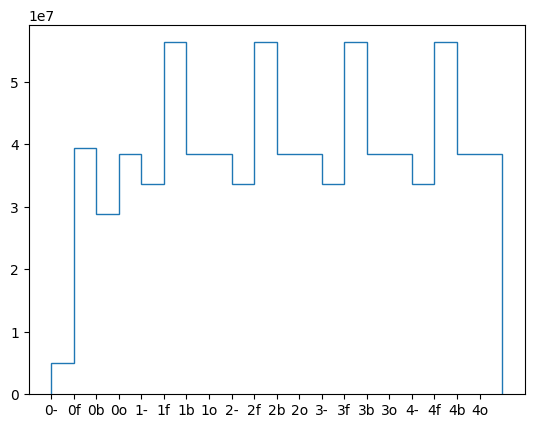

In [ ]:
plot_memory("mem_baseline.csv", 20)

The y-axis is the number of bytes allocated on a GPU, while on the x-axis, the number is the batch number, and the letter means:
- -: begin of the batch
- f: after forward pass
- b: after backward pass
- o: after optimizer

### DDP Experiment

Now let's train the same network using DDP, and compare the training time and memory usage

In [ ]:
%%file ddp.py
import os
import argparse
import functools
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.profiler
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
from torch.distributed.fsdp import FullyShardedDataParallel as FSDP
from torch.distributed.fsdp.fully_sharded_data_parallel import (
    CPUOffload,
    BackwardPrefetch,
)
from torch.distributed.fsdp.wrap import (
    size_based_auto_wrap_policy,
    enable_wrap,
    wrap,
)

def setup(rank, world_size):
    os.environ['MASTER_ADDR'] = 'localhost'
    os.environ['MASTER_PORT'] = '12355'

    # initialize the process group
    dist.init_process_group("cpu:gloo,cuda:nccl", rank=rank, world_size=world_size)

def cleanup():
    dist.destroy_process_group()

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1) # 352 parameters
        self.conv2 = nn.Conv2d(32, 64, 3, 1) # 18 496 parameters
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128) # 1 179 776 parameters
        self.fc2 = nn.Linear(128, 10) # 1290 parameters

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

def train(args, model, rank, world_size, train_loader, optimizer, epoch, sampler=None):
    model.train()
    ddp_loss = torch.zeros(2).to(rank)
    alloc_mem_size = 4 * len(train_loader)
    alloc_mem = torch.zeros(alloc_mem_size)
    if sampler:
        sampler.set_epoch(epoch)
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(rank), target.to(rank)
        optimizer.zero_grad()
        alloc_mem[batch_idx * 4] = torch.cuda.memory_allocated(rank)
        output = model(data)
        alloc_mem[batch_idx * 4 + 1] = torch.cuda.memory_allocated(rank)
        loss = F.nll_loss(output, target, reduction='sum')
        loss.backward()
        alloc_mem[batch_idx * 4 + 2] = torch.cuda.memory_allocated(rank)
        optimizer.step()
        alloc_mem[batch_idx * 4 + 3] = torch.cuda.memory_allocated(rank)
        ddp_loss[0] += loss.item()
        ddp_loss[1] += len(data)

    dist.all_reduce(ddp_loss, op=dist.ReduceOp.SUM)
    if rank == 0:
        print('Train Epoch: {} \tLoss: {:.6f}'.format(epoch, ddp_loss[0] / ddp_loss[1]))

    alloc_gather = None
    if rank == 0:
        alloc_gather = [torch.zeros(alloc_mem_size) for _ in range(world_size)]
    dist.gather(alloc_mem, alloc_gather, dst=0)
    if rank == 0:
        pd.DataFrame([t.numpy() for t in alloc_gather]).to_csv("mem_log.csv", index=False)

def test(model, rank, world_size, test_loader):
    model.eval()
    correct = 0
    ddp_loss = torch.zeros(3).to(rank)
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(rank), target.to(rank)
            output = model(data)
            ddp_loss[0] += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            ddp_loss[1] += pred.eq(target.view_as(pred)).sum().item()
            ddp_loss[2] += len(data)

    dist.all_reduce(ddp_loss, op=dist.ReduceOp.SUM)

    if rank == 0:
        test_loss = ddp_loss[0] / ddp_loss[2]
        print('Test set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
            test_loss, int(ddp_loss[1]), int(ddp_loss[2]),
            100. * ddp_loss[1] / ddp_loss[2]))

def fsdp_main(rank, world_size, args):
    setup(rank, world_size)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    dataset_train = datasets.MNIST('./data', train=True, download=True,
                        transform=transform)
    dataset_test = datasets.MNIST('./data', train=False,
                        transform=transform)

    sampler_train = DistributedSampler(dataset_train, rank=rank, num_replicas=world_size, shuffle=True)
    sampler_test = DistributedSampler(dataset_test, rank=rank, num_replicas=world_size)

    train_kwargs = {'batch_size': args.batch_size, 'sampler': sampler_train}
    test_kwargs = {'batch_size': args.test_batch_size, 'sampler': sampler_test}
    cuda_kwargs = {'num_workers': 2,
                    'pin_memory': True,
                    'shuffle': False}
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)

    train_loader = torch.utils.data.DataLoader(dataset_train,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset_test, **test_kwargs)

    torch.cuda.set_device(rank)

    init_start_event = torch.cuda.Event(enable_timing=True)
    init_end_event = torch.cuda.Event(enable_timing=True)

    model = Net()

    model = DDP(model).to(rank)

    optimizer = optim.Adadelta(model.parameters(), lr=args.lr)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)

    init_start_event.record()
    for epoch in range(1, args.epochs + 1):
        train(args, model, rank, world_size, train_loader, optimizer, epoch, sampler=sampler_train)
        test(model, rank, world_size, test_loader)
        scheduler.step()

    init_end_event.record()

    if rank == 0:
        print(f"CUDA event elapsed time: {init_start_event.elapsed_time(init_end_event) / 1000}sec")
        print(f"{model}")

    if args.save_model:
        # use a barrier to make sure training is done on all ranks
        dist.barrier()
        states = model.state_dict()
        if rank == 0:
            torch.save(states, "mnist_cnn.pt")

    cleanup()

if __name__ == '__main__':
    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=1, metavar='N',
                        help='number of epochs to train (default: 1)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-cuda', action='store_true', default=False,
                        help='disables CUDA training')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--save-model', action='store_true', default=False,
                        help='For Saving the current Model')
    args = parser.parse_args()

    torch.manual_seed(args.seed)

    WORLD_SIZE = torch.cuda.device_count()

    print(f"WORLD_SIZE = {WORLD_SIZE}")

    mp.spawn(fsdp_main,
        args=(WORLD_SIZE, args),
        nprocs=WORLD_SIZE,
        join=True)

Writing ddp.py


In [ ]:
!scp -i .ssh/id_ed25519 ddp.py $ENTROPY_LOGIN@entropy.mimuw.edu.pl:~/lml_labs/
!ssh -i .ssh/id_ed25519 $ENTROPY_LOGIN@entropy.mimuw.edu.pl "source venv_lml/bin/activate && srun --partition=common --qos=kp438667_bml_common --time=30 --gres=gpu:4 python lml_labs/ddp.py"

WORLD_SIZE = 4
[Gloo] Rank 0 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 2 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 3 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 1 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
Train Epoch: 1 	Loss: 0.369522
Test set: Average loss: 0.0868, Accuracy: 9742/10000 (97.42%)

CUDA event elapsed time: 19.526814453125sec
DistributedDataParallel(
  (module): Net(
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (dropout1): Dropout(p=0.25, inplace=False)
    (dropout2): Dropout(p=0.5, inplace=False)
    (fc1): Linear(in_features=9216, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
!scp -i .ssh/id_ed25519 $ENTROPY_LOGIN@entropy.mimuw.edu.pl:mem_log.csv ./mem_ddp.csv

(4, 20)


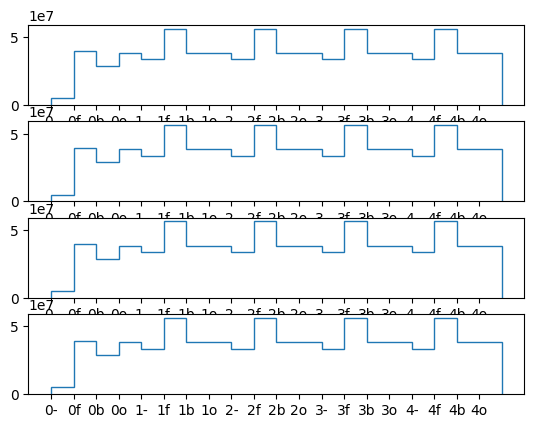

In [ ]:
plot_memory("mem_ddp.csv", 20)

There may be slight lower memory consumption (because of the optimizer states and activations), but the time of training probably won't improve, because the model and the batch size is relatively small - try to increase the batch size (parameter `--batch-size` in the command line), and see what happens.

### FSDP Experiment
One advantage of FSDP is that to convert your model from DDP to FSDP, you actually need to change only one line:
- Change the line `model = DDP(model)` in the `fsdp_main` function.
- To the line `model = FSDP(model)`.

Note: it will create model with only one FSDP Unit.

In [ ]:
%%file fsdp.py
#TODO: paste the previous file here and modify it

import os
import argparse
import functools
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.profiler
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
from torch.distributed.fsdp import FullyShardedDataParallel as FSDP
from torch.distributed.fsdp.fully_sharded_data_parallel import (
    CPUOffload,
    BackwardPrefetch,
)
from torch.distributed.fsdp.wrap import (
    size_based_auto_wrap_policy,
    enable_wrap,
    wrap,
)

def setup(rank, world_size):
    os.environ['MASTER_ADDR'] = 'localhost'
    os.environ['MASTER_PORT'] = '12355'

    # initialize the process group
    dist.init_process_group("cpu:gloo,cuda:nccl", rank=rank, world_size=world_size)

def cleanup():
    dist.destroy_process_group()

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1) # 352 parameters
        self.conv2 = nn.Conv2d(32, 64, 3, 1) # 18 496 parameters
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128) # 1 179 776 parameters
        self.fc2 = nn.Linear(128, 10) # 1290 parameters

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

def train(args, model, rank, world_size, train_loader, optimizer, epoch, sampler=None):
    model.train()
    ddp_loss = torch.zeros(2).to(rank)
    alloc_mem_size = 4 * len(train_loader)
    alloc_mem = torch.zeros(alloc_mem_size)
    if sampler:
        sampler.set_epoch(epoch)
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(rank), target.to(rank)
        optimizer.zero_grad()
        alloc_mem[batch_idx * 4] = torch.cuda.memory_allocated(rank)
        output = model(data)
        alloc_mem[batch_idx * 4 + 1] = torch.cuda.memory_allocated(rank)
        loss = F.nll_loss(output, target, reduction='sum')
        loss.backward()
        alloc_mem[batch_idx * 4 + 2] = torch.cuda.memory_allocated(rank)
        optimizer.step()
        alloc_mem[batch_idx * 4 + 3] = torch.cuda.memory_allocated(rank)
        ddp_loss[0] += loss.item()
        ddp_loss[1] += len(data)

    dist.all_reduce(ddp_loss, op=dist.ReduceOp.SUM)
    if rank == 0:
        print('Train Epoch: {} \tLoss: {:.6f}'.format(epoch, ddp_loss[0] / ddp_loss[1]))

    alloc_gather = None
    if rank == 0:
        alloc_gather = [torch.zeros(alloc_mem_size) for _ in range(world_size)]
    dist.gather(alloc_mem, alloc_gather, dst=0)
    if rank == 0:
        pd.DataFrame([t.numpy() for t in alloc_gather]).to_csv("mem_log.csv", index=False)

def test(model, rank, world_size, test_loader):
    model.eval()
    correct = 0
    ddp_loss = torch.zeros(3).to(rank)
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(rank), target.to(rank)
            output = model(data)
            ddp_loss[0] += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            ddp_loss[1] += pred.eq(target.view_as(pred)).sum().item()
            ddp_loss[2] += len(data)

    dist.all_reduce(ddp_loss, op=dist.ReduceOp.SUM)

    if rank == 0:
        test_loss = ddp_loss[0] / ddp_loss[2]
        print('Test set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
            test_loss, int(ddp_loss[1]), int(ddp_loss[2]),
            100. * ddp_loss[1] / ddp_loss[2]))

def fsdp_main(rank, world_size, args):
    setup(rank, world_size)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    dataset_train = datasets.MNIST('./data', train=True, download=True,
                        transform=transform)
    dataset_test = datasets.MNIST('./data', train=False,
                        transform=transform)

    sampler_train = DistributedSampler(dataset_train, rank=rank, num_replicas=world_size, shuffle=True)
    sampler_test = DistributedSampler(dataset_test, rank=rank, num_replicas=world_size)

    train_kwargs = {'batch_size': args.batch_size, 'sampler': sampler_train}
    test_kwargs = {'batch_size': args.test_batch_size, 'sampler': sampler_test}
    cuda_kwargs = {'num_workers': 2,
                    'pin_memory': True,
                    'shuffle': False}
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)

    train_loader = torch.utils.data.DataLoader(dataset_train,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset_test, **test_kwargs)

    torch.cuda.set_device(rank)

    init_start_event = torch.cuda.Event(enable_timing=True)
    init_end_event = torch.cuda.Event(enable_timing=True)

    model = Net()

    model = FSDP(model).to(rank)

    optimizer = optim.Adadelta(model.parameters(), lr=args.lr)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)

    init_start_event.record()
    for epoch in range(1, args.epochs + 1):
        train(args, model, rank, world_size, train_loader, optimizer, epoch, sampler=sampler_train)
        test(model, rank, world_size, test_loader)
        scheduler.step()

    init_end_event.record()

    if rank == 0:
        print(f"CUDA event elapsed time: {init_start_event.elapsed_time(init_end_event) / 1000}sec")
        print(f"{model}")

    if args.save_model:
        # use a barrier to make sure training is done on all ranks
        dist.barrier()
        states = model.state_dict()
        if rank == 0:
            torch.save(states, "mnist_cnn.pt")

    cleanup()

if __name__ == '__main__':
    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=1, metavar='N',
                        help='number of epochs to train (default: 1)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-cuda', action='store_true', default=False,
                        help='disables CUDA training')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--save-model', action='store_true', default=False,
                        help='For Saving the current Model')
    args = parser.parse_args()

    torch.manual_seed(args.seed)

    WORLD_SIZE = torch.cuda.device_count()

    print(f"WORLD_SIZE = {WORLD_SIZE}")

    mp.spawn(fsdp_main,
        args=(WORLD_SIZE, args),
        nprocs=WORLD_SIZE,
        join=True)

Writing fsdp.py


In [ ]:
!scp -i .ssh/id_ed25519 fsdp.py $ENTROPY_LOGIN@entropy.mimuw.edu.pl:~/lml_labs/
!ssh -i .ssh/id_ed25519 $ENTROPY_LOGIN@entropy.mimuw.edu.pl "source venv_lml/bin/activate && srun --partition=common --qos=kp438667_bml_common --time=30 --gres=gpu:4 python lml_labs/fsdp.py"

WORLD_SIZE = 4
[Gloo] Rank 0 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 2 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 1 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 3 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
/home/kp438667/venv_lml/lib/python3.12/site-packages/torch/distributed/fsdp/_init_utils.py:1031: UserWarning: The passed-in `module` is on CPU and will thus have FSDP's sharding initialization run on CPU, which may be slower than on GPU. We recommend passing in the `device_id` argument for FSDP to move `module` to GPU for the sharding initialization. `module` must also be on GPU device to work with the `sync_module_states=True` flag since that requires GPU communication.
  warnings.warn(
/home/kp438667/venv_lml/lib/python3.12/site-packages/torch/distributed/fsdp/_init_utils.py:1031: UserWarning: The passed-in `mod

In [ ]:
!scp -i .ssh/id_ed25519 $ENTROPY_LOGIN@entropy.mimuw.edu.pl:mem_log.csv ./mem_fsdp.csv

(4, 20)


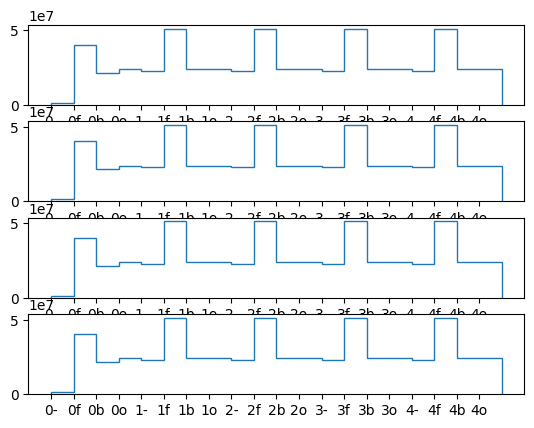

In [ ]:
plot_memory("mem_fsdp.csv", 20)

FSDP with only one unit is almost the same algorithm as DDP, so the results here should be similar as in previous experiment.

### FSPD with wrapping policy
There is an automatic way to shard model onto many FSDP units: `auto_wrap_policy`, which is a function that for each layer decides wheter to put it into separate unit.

Add the lines:
```
my_auto_wrap_policy = functools.partial(
        size_based_auto_wrap_policy, min_num_params=100
    )
model = FSDP(model, auto_wrap_policy=my_auto_wrap_policy)
```
instead of the line
```
model = FSDP(model)
```
to the code above. The parameter `min_num_params` controls how many parameters a layer needs to have to become new FSDP Unit. Setting it to 100 will cause that every layer will become its own unit. Try to experiment with this parameter, or other auto wrap policies, that you can find [here](https://github.com/pytorch/pytorch/blob/main/torch/distributed/fsdp/wrap.py).

In [ ]:
%%file fsdp-wrap.py
#TODO: paste the previous file here and modify it
import os
import argparse
import functools
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.profiler
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
from torch.distributed.fsdp import FullyShardedDataParallel as FSDP
from torch.distributed.fsdp.fully_sharded_data_parallel import (
    CPUOffload,
    BackwardPrefetch,
)
from torch.distributed.fsdp.wrap import (
    size_based_auto_wrap_policy,
    enable_wrap,
    wrap,
)

def setup(rank, world_size):
    os.environ['MASTER_ADDR'] = 'localhost'
    os.environ['MASTER_PORT'] = '12355'

    # initialize the process group
    dist.init_process_group("cpu:gloo,cuda:nccl", rank=rank, world_size=world_size)

def cleanup():
    dist.destroy_process_group()

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1) # 352 parameters
        self.conv2 = nn.Conv2d(32, 64, 3, 1) # 18 496 parameters
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128) # 1 179 776 parameters
        self.fc2 = nn.Linear(128, 10) # 1290 parameters

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

def train(args, model, rank, world_size, train_loader, optimizer, epoch, sampler=None):
    model.train()
    ddp_loss = torch.zeros(2).to(rank)
    alloc_mem_size = 4 * len(train_loader)
    alloc_mem = torch.zeros(alloc_mem_size)
    if sampler:
        sampler.set_epoch(epoch)
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(rank), target.to(rank)
        optimizer.zero_grad()
        alloc_mem[batch_idx * 4] = torch.cuda.memory_allocated(rank)
        output = model(data)
        alloc_mem[batch_idx * 4 + 1] = torch.cuda.memory_allocated(rank)
        loss = F.nll_loss(output, target, reduction='sum')
        loss.backward()
        alloc_mem[batch_idx * 4 + 2] = torch.cuda.memory_allocated(rank)
        optimizer.step()
        alloc_mem[batch_idx * 4 + 3] = torch.cuda.memory_allocated(rank)
        ddp_loss[0] += loss.item()
        ddp_loss[1] += len(data)

    dist.all_reduce(ddp_loss, op=dist.ReduceOp.SUM)
    if rank == 0:
        print('Train Epoch: {} \tLoss: {:.6f}'.format(epoch, ddp_loss[0] / ddp_loss[1]))

    alloc_gather = None
    if rank == 0:
        alloc_gather = [torch.zeros(alloc_mem_size) for _ in range(world_size)]
    dist.gather(alloc_mem, alloc_gather, dst=0)
    if rank == 0:
        pd.DataFrame([t.numpy() for t in alloc_gather]).to_csv("mem_log.csv", index=False)

def test(model, rank, world_size, test_loader):
    model.eval()
    correct = 0
    ddp_loss = torch.zeros(3).to(rank)
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(rank), target.to(rank)
            output = model(data)
            ddp_loss[0] += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            ddp_loss[1] += pred.eq(target.view_as(pred)).sum().item()
            ddp_loss[2] += len(data)

    dist.all_reduce(ddp_loss, op=dist.ReduceOp.SUM)

    if rank == 0:
        test_loss = ddp_loss[0] / ddp_loss[2]
        print('Test set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
            test_loss, int(ddp_loss[1]), int(ddp_loss[2]),
            100. * ddp_loss[1] / ddp_loss[2]))

def fsdp_main(rank, world_size, args):
    setup(rank, world_size)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    dataset_train = datasets.MNIST('./data', train=True, download=True,
                        transform=transform)
    dataset_test = datasets.MNIST('./data', train=False,
                        transform=transform)

    sampler_train = DistributedSampler(dataset_train, rank=rank, num_replicas=world_size, shuffle=True)
    sampler_test = DistributedSampler(dataset_test, rank=rank, num_replicas=world_size)

    train_kwargs = {'batch_size': args.batch_size, 'sampler': sampler_train}
    test_kwargs = {'batch_size': args.test_batch_size, 'sampler': sampler_test}
    cuda_kwargs = {'num_workers': 2,
                    'pin_memory': True,
                    'shuffle': False}
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)

    train_loader = torch.utils.data.DataLoader(dataset_train,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset_test, **test_kwargs)

    torch.cuda.set_device(rank)

    init_start_event = torch.cuda.Event(enable_timing=True)
    init_end_event = torch.cuda.Event(enable_timing=True)

    model = Net()

    my_auto_wrap_policy = functools.partial(
        size_based_auto_wrap_policy, min_num_params=100
    )
    model = FSDP(model, auto_wrap_policy=my_auto_wrap_policy)


    model = FSDP(model).to(rank)

    optimizer = optim.Adadelta(model.parameters(), lr=args.lr)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)

    init_start_event.record()
    for epoch in range(1, args.epochs + 1):
        train(args, model, rank, world_size, train_loader, optimizer, epoch, sampler=sampler_train)
        test(model, rank, world_size, test_loader)
        scheduler.step()

    init_end_event.record()

    if rank == 0:
        print(f"CUDA event elapsed time: {init_start_event.elapsed_time(init_end_event) / 1000}sec")
        print(f"{model}")

    if args.save_model:
        # use a barrier to make sure training is done on all ranks
        dist.barrier()
        states = model.state_dict()
        if rank == 0:
            torch.save(states, "mnist_cnn.pt")

    cleanup()

if __name__ == '__main__':
    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=1, metavar='N',
                        help='number of epochs to train (default: 1)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-cuda', action='store_true', default=False,
                        help='disables CUDA training')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--save-model', action='store_true', default=False,
                        help='For Saving the current Model')
    args = parser.parse_args()

    torch.manual_seed(args.seed)

    WORLD_SIZE = torch.cuda.device_count()

    print(f"WORLD_SIZE = {WORLD_SIZE}")

    mp.spawn(fsdp_main,
        args=(WORLD_SIZE, args),
        nprocs=WORLD_SIZE,
        join=True)

Writing fsdp-wrap.py


In [ ]:
!scp -i .ssh/id_ed25519 fsdp-wrap.py $ENTROPY_LOGIN@entropy.mimuw.edu.pl:~/lml_labs/
!ssh -i .ssh/id_ed25519 $ENTROPY_LOGIN@entropy.mimuw.edu.pl "source venv_lml/bin/activate && srun --partition=common --qos=kp438667_bml_common --time=30 --gres=gpu:4 python lml_labs/fsdp-wrap.py"

WORLD_SIZE = 4
[Gloo] Rank 2 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 1 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 0 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 3 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
/home/kp438667/venv_lml/lib/python3.12/site-packages/torch/distributed/fsdp/_init_utils.py:1031: UserWarning: The passed-in `module` is on CPU and will thus have FSDP's sharding initialization run on CPU, which may be slower than on GPU. We recommend passing in the `device_id` argument for FSDP to move `module` to GPU for the sharding initialization. `module` must also be on GPU device to work with the `sync_module_states=True` flag since that requires GPU communication.
  warnings.warn(
/home/kp438667/venv_lml/lib/python3.12/site-packages/torch/distributed/fsdp/_init_utils.py:1031: UserWarning: The passed-in `mod

In [ ]:
!scp -i .ssh/id_ed25519 $ENTROPY_LOGIN@entropy.mimuw.edu.pl:mem_log.csv ./mem_wrap.csv

(4, 20)


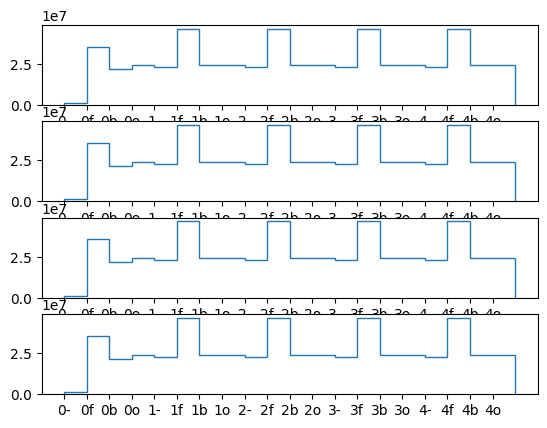

In [ ]:
plot_memory("mem_wrap.csv", 20)

Here we should see significant decrease of memory (especially in the case in which every layer is in its own FSDP unit), but at the expense of slightly higher training time.

### Large model experiment

Let's start from downloading the data: wikihow dataset.

In [ ]:
!ssh -i .ssh/id_ed25519 $ENTROPY_LOGIN@entropy.mimuw.edu.pl "cd data && wget data https://public-nlp-datasets.s3.us-west-2.amazonaws.com/wikihowAll.csv && wget data https://public-nlp-datasets.s3.us-west-2.amazonaws.com/wikihowSep.csv"

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
355000K .......... .......... .......... .......... .......... 58%  127M 13s
355050K .......... .......... .......... .......... .......... 58% 87.6M 13s
355100K .......... .......... .......... .......... .......... 58%  111M 13s
355150K .......... .......... .......... .......... .......... 58%  129M 13s
355200K .......... .......... .......... .......... .......... 58% 96.0M 13s
355250K .......... .......... .......... .......... .......... 58%  122M 13s
355300K .......... .......... .......... .......... .......... 58%  105M 13s
355350K .......... .......... .......... .......... .......... 58%  116M 13s
355400K .......... .......... .......... .......... .......... 58%  114M 13s
355450K .......... .......... .......... .......... .......... 58% 90.9M 13s
355500K .......... .......... .......... .......... .......... 58%  113M 13s
355550K .......... .......... .......... .......... .......... 58%  124M 13s
355600K ...

In [ ]:
!ssh -i .ssh/id_ed25519 $ENTROPY_LOGIN@entropy.mimuw.edu.pl "cd data && wget data https://public-nlp-datasets.s3.us-west-2.amazonaws.com/wikihowSep.csv"

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
1011400K .......... .......... .......... .......... .......... 80%  130M 15s
1011450K .......... .......... .......... .......... .......... 80%  134M 15s
1011500K .......... .......... .......... .......... .......... 80%  100M 15s
1011550K .......... .......... .......... .......... .......... 80%  143M 15s
1011600K .......... .......... .......... .......... .......... 80%  132M 15s
1011650K .......... .......... .......... .......... .......... 80%  103M 15s
1011700K .......... .......... .......... .......... .......... 80% 91.1M 15s
1011750K .......... .......... .......... .......... .......... 80%  121M 15s
1011800K .......... .......... .......... .......... .......... 80%  126M 15s
1011850K .......... .......... .......... .......... .......... 80%  107M 15s
1011900K .......... .......... .......... .......... .......... 80%  111M 15s
1011950K .......... .......... .......... .......... .......... 80%  124M 15s

In [ ]:
%%file summarization_dataset.py
import argparse
import glob
import os
import json
import time
import logging
import random
import re
from itertools import chain
from string import punctuation

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

from transformers import (
    # AdamW, # STUDENT'S FIX - optim.AdamW is now
    T5ForConditionalGeneration,
    T5Tokenizer,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW # Students fix

class wikihow(Dataset):
    def __init__(self, tokenizer, type_path, num_samples, input_length, output_length, print_text=False):
        # self.dataset =  load_dataset('wikihow', 'all', data_dir='data/', split=type_path) # Again - students fix
        # data_dir = os.path.expanduser("~/data")
        # self.dataset = load_dataset(
        #     "csv",
        #     data_files={
        #         "train": os.path.join(data_dir, "wikihowAll.csv"),
        #         "validation": os.path.join(data_dir, "wikihowSep.csv")
        #     },
        #     split=type_path
        # )
        self.dataset = load_dataset(
            "csv",
            data_files={
                "train": os.path.expanduser("~/data/wikihowAll.csv"),
                "validation": os.path.expanduser("~/data/wikihowSep_clean.csv")
            }
        )
        if num_samples:
            self.dataset = self.dataset.select(list(range(0, num_samples)))
        self.input_length = input_length
        self.tokenizer = tokenizer
        self.output_length = output_length
        self.print_text = print_text

    def __len__(self):
        return self.dataset.shape[0]

    def clean_text(self, text):
        text = text.replace('Example of text:', '')
        text = text.replace('Example of Summary:', '')
        text = text.replace('\n','')
        text = text.replace('``', '')
        text = text.replace('"', '')

        return text


    def convert_to_features(self, example_batch):
        # Tokenize contexts and questions (as pairs of inputs)

        if self.print_text:
            print("Input Text: ", self.clean_text(example_batch['text']))
#         input_ = self.clean_text(example_batch['text']) + " </s>"
#         target_ = self.clean_text(example_batch['headline']) + " </s>"

        input_ = self.clean_text(example_batch['text'])
        target_ = self.clean_text(example_batch['headline'])

        source = self.tokenizer.batch_encode_plus([input_], max_length=self.input_length,
                                                     padding='max_length', truncation=True, return_tensors="pt")

        targets = self.tokenizer.batch_encode_plus([target_], max_length=self.output_length,
                                                     padding='max_length', truncation=True, return_tensors="pt")


        return source, targets

    def __getitem__(self, index):
        source, targets = self.convert_to_features(self.dataset[index])

        source_ids = source["input_ids"].squeeze()
        target_ids = targets["input_ids"].squeeze()

        src_mask    = source["attention_mask"].squeeze()
        target_mask = targets["attention_mask"].squeeze()

        return {"source_ids": source_ids, "source_mask": src_mask, "target_ids": target_ids, "target_mask": target_mask}

def get_dataset(tokenizer, type_path, num_samples, args):
      return wikihow(tokenizer=tokenizer, type_path=type_path, num_samples=num_samples,  input_length=max_input_length,
                        output_length=max_output_length)

Overwriting summarization_dataset.py


In [ ]:
!scp -i .ssh/id_ed25519 summarization_dataset.py $ENTROPY_LOGIN@entropy.mimuw.edu.pl:~/lml_labs/

In [ ]:
%%file t5.py
import os
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from transformers import AutoTokenizer, GPT2TokenizerFast
from transformers import T5Tokenizer, T5ForConditionalGeneration
import functools
from torch.optim.lr_scheduler import StepLR
import torch.nn.functional as F
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
from transformers.models.t5.modeling_t5 import T5Block

from torch.distributed.algorithms._checkpoint.checkpoint_wrapper import (
 checkpoint_wrapper,
 CheckpointImpl,
 apply_activation_checkpointing)

from torch.distributed.fsdp import (
    FullyShardedDataParallel as FSDP,
    MixedPrecision,
    BackwardPrefetch,
    ShardingStrategy,
    FullStateDictConfig,
    StateDictType,
)
from torch.distributed.fsdp.wrap import (
    transformer_auto_wrap_policy,
    enable_wrap,
    wrap,
)
from functools import partial
from torch.utils.data import DataLoader
from pathlib import Path
from summarization_dataset import *
from transformers.models.t5.modeling_t5 import T5Block
from typing import Type
import time
import tqdm
from datetime import datetime

def setup():
    # initialize the process group
    dist.init_process_group("nccl")

def cleanup():
    dist.destroy_process_group()

def setup_model(model_name):
    model = T5ForConditionalGeneration.from_pretrained(model_name)
    tokenizer =  T5Tokenizer.from_pretrained(model_name)
    return model, tokenizer

def get_date_of_run():
    """create date and time for file save uniqueness
    example: 2022-05-07-08:31:12_PM'
    """
    date_of_run = datetime.now().strftime("%Y-%m-%d-%I:%M:%S_%p")
    print(f"--> current date and time of run = {date_of_run}")
    return date_of_run

def format_metrics_to_gb(item):
    """quick function to format numbers to gigabyte and round to 4 digit precision"""
    metric_num = item / (1024 * 1024)
    metric_num = round(metric_num, ndigits=4)
    return metric_num

def train(args, model, rank, world_size, train_loader, optimizer, epoch, sampler=None):
    model.train()
    local_rank = int(os.environ['LOCAL_RANK'])
    fsdp_loss = torch.zeros(2).to(local_rank)

    if sampler:
        sampler.set_epoch(epoch)
    if rank==0:
        inner_pbar = tqdm.tqdm(
            range(len(train_loader)), colour="blue", desc="r0 Training Epoch"
        )
    for batch in train_loader:
        for key in batch.keys():
            batch[key] = batch[key].to(local_rank)
        optimizer.zero_grad()
        output = model(input_ids=batch["source_ids"],attention_mask=batch["source_mask"],labels=batch["target_ids"] )
        loss = output["loss"]
        loss.backward()
        optimizer.step()
        fsdp_loss[0] += loss.item()
        fsdp_loss[1] += len(batch)
        if rank==0:
            inner_pbar.update(1)

    dist.all_reduce(fsdp_loss, op=dist.ReduceOp.SUM)
    train_accuracy = fsdp_loss[0] / fsdp_loss[1]
    if rank == 0:
        inner_pbar.close()
        print(f"Train Epoch: \t{epoch}, Loss: \t{train_accuracy:.4f}")
    return train_accuracy

def validation(model, rank, world_size, val_loader):
    model.eval()
    correct = 0
    local_rank = int(os.environ['LOCAL_RANK'])
    fsdp_loss = torch.zeros(3).to(local_rank)
    if rank == 0:
        inner_pbar = tqdm.tqdm(
            range(len(val_loader)), colour="green", desc="Validation Epoch"
        )
    with torch.no_grad():
        for batch in val_loader:
            for key in batch.keys():
                batch[key] = batch[key].to(local_rank)
            output = model(input_ids=batch["source_ids"],attention_mask=batch["source_mask"],labels=batch["target_ids"])
            fsdp_loss[0] += output["loss"].item()  # sum up batch loss
            fsdp_loss[1] += len(batch)

            if rank==0:
                inner_pbar.update(1)

    dist.all_reduce(fsdp_loss, op=dist.ReduceOp.SUM)
    val_loss = fsdp_loss[0] / fsdp_loss[1]
    if rank == 0:
        inner_pbar.close()
        print(f"Validation Loss: {val_loss:.4f}")
    return val_loss

def fsdp_main(args):
    # The T5 model variants:
    # t5-small: 60 milion parameters
    # t5-base: 220 milion parameters
    # t5-large: 770 milion parameters
    # t5-3b: 3 bilion parameters
    # t5-11b: 11 bilion parameters
    model, tokenizer = setup_model("t5-large")

    local_rank = int(os.environ['LOCAL_RANK'])
    rank = int(os.environ['RANK'])
    world_size = int(os.environ['WORLD_SIZE'])

    # dataset = load_dataset('wikihow', 'all', data_dir='~/data/')
    from datasets import load_dataset
    dataset = load_dataset(
        "csv",
        data_files={
            "train": os.path.expanduser("~/data/wikihowAll.csv"),
            "validation": os.path.expanduser("~/data/wikihowSep_clean.csv") # fix after "cut -d',' -f1-3 wikihowSep.csv > wikihowSep_clean.csv", cause nr of columns different
        },
        # split=type_path
    )
    print(dataset.keys())
    print("Size of train dataset: ", dataset['train'].shape)
    print("Size of Validation dataset: ", dataset['validation'].shape)

    #wikihow(tokenizer, type_path, num_samples, input_length, output_length, print_text=False)
    train_dataset = wikihow(tokenizer, 'train', 1500, 512, 150, False)
    val_dataset = wikihow(tokenizer, 'validation', 300, 512, 150, False)

    sampler1 = DistributedSampler(train_dataset, rank=rank, num_replicas=world_size, shuffle=True)
    sampler2 = DistributedSampler(val_dataset, rank=rank, num_replicas=world_size)

    setup()

    train_kwargs = {'batch_size': args.batch_size, 'sampler': sampler1}
    test_kwargs = {'batch_size': args.test_batch_size, 'sampler': sampler2}
    cuda_kwargs = {'num_workers': 2,
                    'pin_memory': True,
                    'shuffle': False}
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)

    train_loader = torch.utils.data.DataLoader(train_dataset,**train_kwargs)
    val_loader = torch.utils.data.DataLoader(val_dataset, **test_kwargs)

    t5_auto_wrap_policy = functools.partial(
        transformer_auto_wrap_policy,
        transformer_layer_cls={
            T5Block,
        },
    )
    sharding_strategy: ShardingStrategy = ShardingStrategy.FULL_SHARD #SHARD_GRAD_OP
    torch.cuda.set_device(local_rank)

    mp_policy = MixedPrecision(
      param_dtype=torch.bfloat16,
      # Gradient communication precision.
      reduce_dtype=torch.bfloat16,
      # Buffer precision.
      buffer_dtype=torch.bfloat16,
    )

    # model is on CPU before input to FSDP
    model = FSDP(model,
        auto_wrap_policy=t5_auto_wrap_policy,
        mixed_precision=mp_policy,
        sharding_strategy=sharding_strategy,
        device_id=torch.cuda.current_device())

    optimizer = optim.AdamW(model.parameters(), lr=args.lr)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    best_val_loss = float("inf")
    curr_val_loss = float("inf")
    file_save_name = "T5-model-"

    if rank == 0:
        time_of_run = get_date_of_run()
        dur = []
        train_acc_tracking = []
        val_acc_tracking = []
        training_start_time = time.time()

    if rank == 0 and args.track_memory:
        mem_alloc_tracker = []
        mem_reserved_tracker = []

    for epoch in range(1, args.epochs + 1):
        t0 = time.time()
        train_accuracy = train(args, model, rank, world_size, train_loader, optimizer, epoch, sampler=sampler1)
        if args.run_validation:
            curr_val_loss = validation(model, rank, world_size, val_loader)
        scheduler.step()

        if rank == 0:

            print(f"--> epoch {epoch} completed...entering save and stats zone")

            dur.append(time.time() - t0)
            train_acc_tracking.append(train_accuracy.item())

            if args.run_validation:
                val_acc_tracking.append(curr_val_loss.item())

            if args.track_memory:
                mem_alloc_tracker.append(
                    format_metrics_to_gb(torch.cuda.memory_allocated())
                )
                mem_reserved_tracker.append(
                    format_metrics_to_gb(torch.cuda.memory_reserved())
                )
            print(f"completed save and stats zone...")

        if args.save_model and curr_val_loss < best_val_loss:

            # save
            if rank == 0:
                print(f"--> entering save model state")

            save_policy = FullStateDictConfig(offload_to_cpu=True, rank0_only=True)
            with FSDP.state_dict_type(
                model, StateDictType.FULL_STATE_DICT, save_policy
            ):
                cpu_state = model.state_dict()
            #print(f"saving process: rank {rank}  done w state_dict")


            if rank == 0:
                print(f"--> saving model ...")
                currEpoch = (
                    "-" + str(epoch) + "-" + str(round(curr_val_loss.item(), 4)) + ".pt"
                )
                print(f"--> attempting to save model prefix {currEpoch}")
                save_name = file_save_name + "-" + time_of_run + "-" + currEpoch
                print(f"--> saving as model name {save_name}")

                torch.save(cpu_state, save_name)

        if curr_val_loss < best_val_loss:

            best_val_loss = curr_val_loss
            if rank==0:
                print(f"-->>>> New Val Loss Record: {best_val_loss}")

    dist.barrier()
    cleanup()

if __name__ == '__main__':
    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch T5 FSDP Example')
    parser.add_argument('--batch-size', type=int, default=4, metavar='N',
                        help='input batch size for training (default: 4)')
    parser.add_argument('--test-batch-size', type=int, default=4, metavar='N',
                        help='input batch size for testing (default: 4)')
    parser.add_argument('--epochs', type=int, default=2, metavar='N',
                        help='number of epochs to train (default: 2)')
    parser.add_argument('--lr', type=float, default=.002, metavar='LR',
                        help='learning rate (default: .002)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-cuda', action='store_true', default=False,
                        help='disables CUDA training')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--track_memory', action='store_false', default=True,
                        help='track the gpu memory')
    parser.add_argument('--run_validation', action='store_false', default=True,
                        help='running the validation')
    parser.add_argument('--save-model', action='store_false', default=True,
                        help='For Saving the current Model')
    args = parser.parse_args()

    torch.manual_seed(args.seed)

    fsdp_main(args)

Overwriting t5.py


In [ ]:
!scp -i .ssh/id_ed25519 t5.py $ENTROPY_LOGIN@entropy.mimuw.edu.pl:~/lml_labs/

Firstly let's try to train the model on one GPU:

In [ ]:
!ssh -i .ssh/id_ed25519 $ENTROPY_LOGIN@entropy.mimuw.edu.pl "source venv_lml/bin/activate && srun --partition=common --qos=kp438667_bml_common --time=30 --gres=gpu:1 torchrun --nnodes 1 --nproc_per_node 1  lml_labs/t5.py"

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
dict_keys(['train', 'validation'])
Size of train dataset:  (215365, 3)
Size of Validation dataset:  (1585695, 3)
Traceback (most recent call last):
  File "/home/kp438667/lml_labs/t5.py", line 306, in <module>
    fsdp_main(args)
  File "/home/kp438667/lml_labs/t5.py", line 158, in fsdp_main
    train_dataset = wikihow(tokenizer, 'train', 1500, 512, 150, False)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/kp438667/lml_labs/summarization_dataset.py", line 47, in __init__
    self.dataset = self

Training on 1 GPU should fail with the `OutOfMemoryError`. Now let's try to use 4 GPUs:

In [ ]:
!ssh -i .ssh/id_ed25519 $ENTROPY_LOGIN@entropy.mimuw.edu.pl "source venv_lml/bin/activate && srun --partition=common --qos=kp438667_bml_common --time=30 --gres=gpu:4 torchrun --nnodes 1 --nproc_per_node 4 lml_labs/t5.py"

W0114 21:22:10.559000 1502296 torch/distributed/run.py:803] 
W0114 21:22:10.559000 1502296 torch/distributed/run.py:803] *****************************************
W0114 21:22:10.559000 1502296 torch/distributed/run.py:803] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0114 21:22:10.559000 1502296 torch/distributed/run.py:803] *****************************************
Traceback (most recent call last):
  File "/home/kp438667/lml_labs/t5.py", line 39, in <module>
Traceback (most recent call last):
    from summarization_dataset import *
  File "/home/kp438667/lml_labs/t5.py", line 39, in <module>
  File "/home/kp438667/lml_labs/summarization_dataset.py", line 19, in <module>
    from summarization_dataset import *
  File "/home/kp438667/lml_labs/summarization_dataset.py", line 19, in <module>
Traceback (most recent call last)

The training on 4 GPUs should succeed. Try to change the model to larger or smaller version (see the comments at the begin of `fsdp_main` function) and experiment with some tuning methods described in [this guide](https://pytorch.org/tutorials/intermediate/FSDP_adavnced_tutorial.html). For example change the sharding strategy, training precision or wrapping policy. See how it impacts size of the model that can be trained on some, chosen by you, number of GPUs, and how the training speed changes.

## When you finish
Remember to remove the public key from `.ssh/authorized_keys` on entropy - your private key won't be persisted on colab.

## Further reading
 - The original paper on ZeRO: https://arxiv.org/abs/1910.02054
 - The paper on FSDP: https://arxiv.org/abs/2304.11277
 - Presentation from the lecture: https://docs.google.com/presentation/d/e/2PACX-1vQ9enPCFZGOFnn0GKwOqUELY2rGfXEinRWvaDhkZCnaLHh7NOsqsBh7n8lWVGGhHs7_Zfh9ufTvNfgT/pub?start=false&loop=false&delayms=3000#slide=id.g2622c82f5ed_1_0
 - Official FSDP tutorials:
    - Basic https://pytorch.org/tutorials/intermediate/FSDP_tutorial.html
    - Advanced https://pytorch.org/tutorials/intermediate/FSDP_adavnced_tutorial.html

- Other FSDP tutorials:
  - https://openmmlab.medium.com/its-2023-is-pytorch-s-fsdp-the-best-choice-for-training-large-models-fe8d2848832f
  - https://www.youtube.com/watch?v=By_O0k102PY